# Notebook 4: Itô Integral and Applications

**Objective:** Introduce the definition of the Itô integral as a limit of stochastic sums and numerically validate its properties. Specifically, we will calculate the integral $\int_{0}^{T} B_s dBs$ and verify the result using **Itô's Formula** (Itô's Lemma).

### Step 1: Simulation of the Itô Integral Trajectory
We will approximate the Itô integral $\displaystyle\int_{0}^{t} B_s dBs$ by calculating its value at each point in time. This is done through the cumulative sum of the terms of the stochastic sum:

$\displaystyle I_{sim}(t_k) = \sum_{i=0}^{k-1} B_{t_i} (B_{t_{i+1}} - B_{t_i})$

This will give us a complete trajectory for the simulated integral, not just its final value.

### Step 2: Verification with Itô's Formula

Itô's Formula is the analogue of the change of variables or the chain rule for stochastic calculus. For a function $f(t, x)$, its differential is:

$\displaystyle df(t, X_t) = \frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial x} dX_t + \frac{1}{2} \frac{\partial^2 f}{\partial x^2} (dX_t)^2$

For our case, we want to find a function $f(B_t)$ such that its differential helps us solve $\int B_s dBs$. 

Let's try $f(x) = \frac{1}{2}x^2$. In this case:
- $\frac{\partial f}{\partial x} = x$
- $\frac{\partial^2 f}{\partial x^2} = 1$

Applying the formula to $f(B_t) = \frac{1}{2}B_t^2$ (with $X_t=B_t$ and $(dB_t)^2=dt$):

$d(\frac{1}{2}B_t^2) = B_t dB_t + \frac{1}{2}(1)dt$

Integrating from 0 to T:

$\displaystyle\int_{0}^{T} d(\frac{1}{2}B_s^2) = \int_{0}^{T} B_s dBs + \int_{0}^{T} \frac{1}{2}ds$

$\displaystyle\frac{1}{2}B_T^2 - \frac{1}{2}B_0^2 = \int_{0}^{T} B_s dBs + \frac{1}{2}T$

Since $B_0 = 0$, we can solve for the integral:

$\displaystyle\int_{0}^{T} B_s dBs = \frac{1}{2}B_T^2 - \frac{1}{2}T$

Now, we will compare this theoretical result with our simulation.

In [4]:
# Simulation parameters
# Set seed
set.seed(123)
T_final <- 1.0
n_steps <- 1000
dt <- T_final / n_steps
time <- seq(0, T_final, length.out = n_steps + 1)

# 1. Simulate a Brownian Motion trajectory
increments <- rnorm(n_steps, mean = 0, sd = sqrt(dt))
B <- c(0, cumsum(increments)) # B_t trajectory

# 2. Calculate the trajectory of the simulated integral (using cumsum)
summands <- B[1:n_steps] * diff(B)
simulated_integral_path <- c(0, cumsum(summands))

# Print the final result of the simulation
simulated_final_value <- tail(simulated_integral_path, 1)
print(paste("Final value of the simulated integral:", round(simulated_final_value, 4)))

[1] "Final value of the simulated integral: -0.3613"


### Step 3: Graphical Verification with Itô's Formula

Now, we will calculate the trajectory of the theoretical result derived from **Itô's Formula**. As detailed in the document, for this specific case, the solution is:

$\displaystyle\int_{0}^{T} B_s dBs = \frac{1}{2}B_t^2 - \frac{1}{2}T$

Finally, we will plot the theoretical trajectory alongside the simulated trajectory for a direct visual comparison. If the simulation is accurate, the two curves should be almost perfectly aligned.

[1] "Theoretical final value (Itô's Formula): -0.3699"
[1] "Final difference: 0.0086"


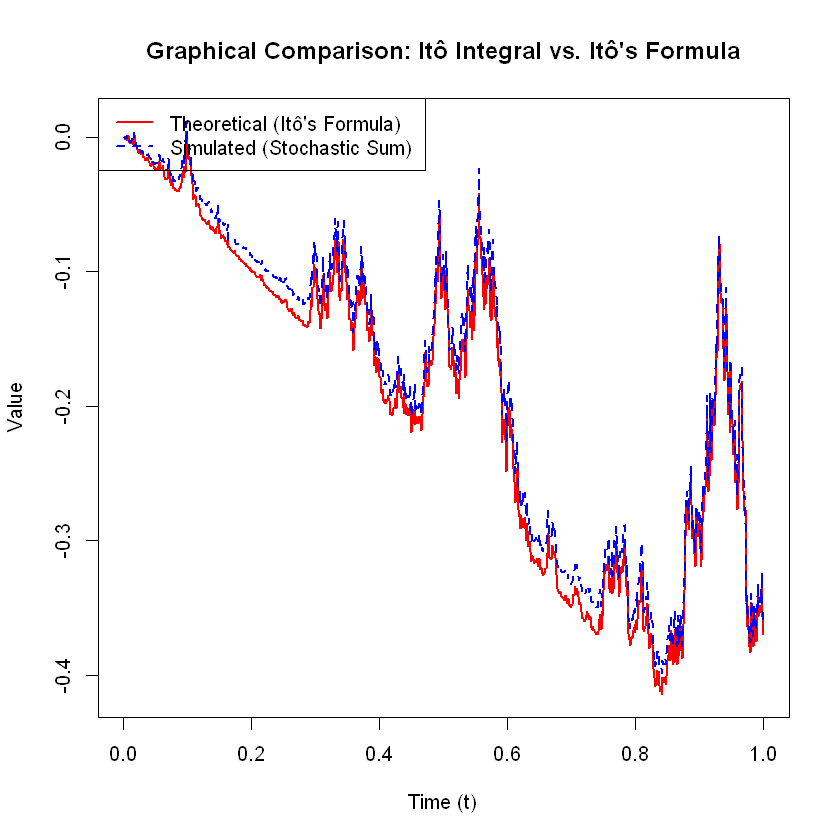

In [5]:
# 1. Calculate the trajectory of the theoretical result
theoretical_result_path <- 0.5 * B^2 - 0.5 * time

# 2. Print the theoretical final result for numerical comparison
theoretical_final_value <- tail(theoretical_result_path, 1)
print(paste("Theoretical final value (Itô's Formula):", round(theoretical_final_value, 4)))
print(paste("Final difference:", round(abs(simulated_final_value - theoretical_final_value), 4)))

# 3. Graphical Visualization
plot(time, theoretical_result_path, type = 'l', col = 'red', lwd = 2,
     main = "Graphical Comparison: Itô Integral vs. Itô's Formula",
     xlab = "Time (t)", ylab = "Value",
     ylim = range(c(theoretical_result_path, simulated_integral_path)))
lines(time, simulated_integral_path, type = 'l', col = 'blue', lty = 2, lwd = 2)
legend("topleft", legend = c("Theoretical (Itô's Formula)", "Simulated (Stochastic Sum)"),
       col = c("red", "blue"), lty = c(1, 2), lwd = 2)